In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV

In [2]:
'''
Function to merge two dataframes
param df1: first dataframe
param df2: second dataframe
return: a single dataframe of the merged dataframes 
'''
def mergeDataframes(df1, df2):
    df = pd.concat([df1, df2])
    return df


'''
Function to merge tournament data for mens and womens and crop the data to match reg detail
params df1: dataframe of mens tournament data
params df2: dataframe of womens tournament data
return: dataframe of combined and cropped tournament data
'''
def mergeTournamentData(df1, df2):
    df1 = df1[df1['Season'] >= 2003].reset_index(drop=True)
    df2 = df2[df2['Season'] >= 2010].reset_index(drop=True)
    
    df = pd.concat([df1, df2])
    return df


'''
Function to split regular season detailed results into dataframes focused on outcome for one team
param df: regular season data
return: a dataframe where each team from a single row in reg data has its own row
'''
def regularDetailsFocus(df):
    RegWinners = pd.DataFrame()
    RegLossers = pd.DataFrame()

    # Establish new columns for that includes stats for one team
    columns = ['Season', 'TeamID', 'DayNum', 'Score', 'OppScore',
               'NumOT', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA',
               'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF', 'OppFGM', 'OppFGA',
               'OppFGM3', 'OppFGA3', 'OppFTM', 'OppFTA', 'OppOR', 'OppDR', 'OppAst', 'OppTO',
               'OppStl', 'OppBlk', 'OppPF']

    # Split winners from regular season
    RegWinners[columns] = df[['Season', 'WTeamID', 'DayNum', 'WScore', 'LScore',
                              'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA',
                              'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA',
                              'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO',
                              'LStl', 'LBlk', 'LPF']]

    # Add wins and losses columns
    RegWinners['Win'] = 1
    RegWinners['Loss'] = 0

    # Split lossers from regular season
    RegLossers[columns] = df[['Season', 'LTeamID', 'DayNum', 'LScore', 'WScore',
                               'NumOT', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA',
                               'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF', 'WFGM', 'WFGA',
                               'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO',
                               'WStl', 'WBlk', 'WPF']]

    # Add wins and losses columns
    RegLossers['Win'] = 0
    RegLossers['Loss'] = 1

    # Combine all games into one dataframe
    AllRegDetail = pd.concat([RegWinners, RegLossers])
    
    return AllRegDetail


'''
Function to clean seed column
param seeds: Dataframe of historical seeds with column 'Seed'
return: A dataframe with the 'Seed' column converted to int
'''
def cleanSeed(seeds):
    seeds['Seed'] = seeds['Seed'].str.extract(r'(\d+)').astype(int)
    return seeds


'''
Function to join two Dataframes on 'TeamID'
param seeds: Dataframe of historical seeds with column 'Seed'
param tourny: Dataframe of compact tournament data with columns 'WTeamID' and 'LTeamID'
return: a single dataframe of the joined Dataframes
'''
def joinSeeds(seeds, tourny):
    seeds = seeds.set_index(['Season','TeamID'])

    tourny = tourny.join(
        seeds.rename(columns={'Seed':'WSeed'}),
        on=['Season','WTeamID']
    )

    tourny = tourny.join(
        seeds.rename(columns={'Seed':'LSeed'}),
        on=['Season','LTeamID']
    )
    return tourny


'''
Helper function to avoid division by 0
'''
def safeDiv(numer, denom):
    return np.divide(
        numer,
        denom,
        out=np.zeros_like(numer, dtype=float),
        where=denom != 0
    )


'''
Function to create the features from the regular season data at a single-game level
param df: dataframe of regular season data
return: dataframe of input features at a single-game level
'''
def createSingleFeatures(df):
    RegSeasonFeatures = pd.DataFrame()
    RegSeasonFeatures[['Season', 'TeamID', 'DayNum']] = df[['Season', 'TeamID', 'DayNum']]

    # RegSeasonFeatures['PointRatio'] = df['Score'] / df['OppScore']  # Points ratio (REMOVED BECAUSE OF CORRELATION)
    # RegSeasonFeatures['MOV'] = df['Score'] - df['OppScore']  # Margin of victory (REMOVED BECAUSE OF CORRELATION)
    RegSeasonFeatures['TORatio'] = safeDiv(df['TO'],df['OppTO'])  # Turnover ratio
    # RegSeasonFeatures['FGM%'] = df['FGM'] / df['FGA']  # Scoring efficiency (REMOVED BECAUSE OF CORRELATION)
    RegSeasonFeatures['FG3%M'] = df['FGM3'] / df['FGA3']  # 3-Point efficiency
    RegSeasonFeatures['FGA3%'] = df['FGA3'] / df['FGA']  # 3-Point attempt rate
    RegSeasonFeatures['FTM%'] = df['FTM'] / df['FTA']  # Free throw makes %
    RegSeasonFeatures['OppFTM%'] = df['OppFTM'] / df['OppFTA']  # Opponent free throw makes %
    RegSeasonFeatures['FTR'] = df['FTA'] / df['FGA']  # Free throw attempt rate
    RegSeasonFeatures['OppFTR'] = df['OppFTA'] / df['OppFGA']  # Opponent free throw attempt rate
    # RegSeasonFeatures['ORRatio'] = df['OR'] / (df['OR'] + df['OppDR'])  # Offensive rebound ratio (REMOVED BECAUSE OF CORRELATION)
    RegSeasonFeatures['DRRatio'] = df['DR'] / (df['DR'] + df['OppOR'])  # Defensive rebound ratio
    
    # New for 2026 (More advanced!)
    RegSeasonFeatures['NumPos'] = df['FGA'] - df['OR'] + df['TO'] + (0.44 * df['FTA'])  # ROUGH estimation of positions
    RegSeasonFeatures['OffEff'] = df['Score'] / RegSeasonFeatures['NumPos']  # Offensive efficiency
    RegSeasonFeatures['DefEff'] = df['OppScore'] / RegSeasonFeatures['NumPos']  # Defensive efficiency
    RegSeasonFeatures['NetEff'] = RegSeasonFeatures['OffEff'] - RegSeasonFeatures['DefEff']  # Net efficiency
    RegSeasonFeatures['TO%'] = df['TO'] / RegSeasonFeatures['NumPos']  # Turnover %
    RegSeasonFeatures['Ast%'] = df['Ast'] / df['FGM']  # Assist percentage
    RegSeasonFeatures['AstTORatio'] = safeDiv(df['Ast'], df['TO'])  # Assist to turnover ratio
    RegSeasonFeatures['AstRatio'] = safeDiv(df['Ast'], df['OppAst'])  # Assist ratio
    RegSeasonFeatures['OR%'] = df['OR'] / (df['FGA'] - df['FGM'])  # Offensive rebound %
    RegSeasonFeatures['DR%'] = df['DR'] / (df['OppFGA'] - df['OppFGM'])  # Defensive rebound %
    # RegSeasonFeatures['EffFG%'] = (df['FGM'] + (0.5 * df['FGM3'])) / df['FGA']  # Effective field goal % (REMOVED BECAUSE OF CORRELATION)
    RegSeasonFeatures['TS%'] = df['Score'] / (2 * (df['FGA'] + (0.44 * df['FTA'])))  # True shot %
    
    return RegSeasonFeatures


'''
Function to create the final features for input to the model
param df1: dataframe of single-game features
param df2: dataframe of regular season boxscore with columns ['Win', 'Loss']
return: dataframe of final input features
'''
def finalFeatures(df1, df2):
    # Season Average Features
    seasonAvg = df1.drop(columns='DayNum').groupby(['Season', 'TeamID']).mean().reset_index()
    
    # Get a win %
    winLoss = df2.groupby(['Season','TeamID'])[['Win', 'Loss']].sum().reset_index()
    winLoss['W/L'] = winLoss['Win'] / (winLoss['Win'] + winLoss['Loss'])  # Win/Loss ratio
    winLoss = winLoss.drop(['Win', 'Loss'], axis=1)
    
    # Merge season avg with win/loss
    finalSeasonAvg = pd.merge(seasonAvg, winLoss)
    
    # Rename columns appropriately
    finalSeasonAvg.columns = ['Season', 'TeamID'] + [f'Season_Avg_{col}' for col in finalSeasonAvg.columns if col not in ['Season', 'TeamID']]
    
    # Get the last 5 of the features
    lastFiveAvg = df1.sort_values(['Season', 'TeamID', 'DayNum']).groupby(['Season', 'TeamID']).tail(5).drop(columns='DayNum').groupby(['Season', 'TeamID']).mean().reset_index()
    lastFiveAvg.columns = ['Season', 'TeamID'] + [f'Last_5_Avg_{col}' for col in lastFiveAvg.columns if col not in ['Season', 'TeamID']]

    # Merge the season with rolling
    features = pd.merge(finalSeasonAvg, lastFiveAvg)
    return features


'''
Function to split tournament data to match the format of input features
param df: dataframe of compact tournament data
return: dataframe of tournament data ready to merge with features
'''
def splitHistTournamentData(df):
    WTourney = pd.DataFrame()
    LTourney = pd.DataFrame()
    
    # Setup separate dataframes for tournament data and add target feature
    WTourney[['Season', 'Team1', 'Team2', 'Team1Seed', 'Team2Seed']] = df[['Season', 'WTeamID', 'LTeamID', 'WSeed', 'LSeed']]
    WTourney['Result'] = 1

    LTourney[['Season', 'Team1', 'Team2', 'Team1Seed', 'Team2Seed']] = df[['Season', 'LTeamID', 'WTeamID', 'LSeed', 'WSeed']]
    LTourney['Result'] = 0

    # Join individual together
    TourneyInput = pd.concat([WTourney, LTourney])
    return TourneyInput


'''
Function to calculate difference in teams input features for historical tournament matchups for LR
param df1: dataframe of tournament data
param df2: dataframe of input features
return: dataframe of differences for training
'''
def calculateDifferenceHistTourn(df1, df2):
    # Merge two team stats from RegSeasonFeatures
    TourneyFinal = df1.merge(df2, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], suffixes=('', '_T1'))
    TourneyFinal = TourneyFinal.merge(df2, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], suffixes=('_T1', '_T2'))
    TourneyFinal[['Seed_T1', 'Seed_T2']] = TourneyFinal[['Team1Seed', 'Team2Seed']]

    # Calculate the differences (Team1 - Team2) for the features for input
    featureCols = [col for col in df2 if col not in ['Season', 'TeamID']] + ['Seed']
    for col in featureCols:
        TourneyFinal[col + '_Diff'] = TourneyFinal[col + '_T1'] - TourneyFinal[col + '_T2']

    # Drop all _T1 and _T2, keep only _Diff and Result
    TourneyFinal = TourneyFinal[['Season', 'Team1', 'Team2'] + [col + '_Diff' for col in featureCols] + ['Result']]
    return TourneyFinal


'''
Function to handle setting up train/test split
param df: dataframe of features
param year: int of the year to be the test set
return: 4 dataframes containing xtrain, xtest, ytrain, and ytest
'''
def trainTestSplit(df, year):
    # Setup input and target
    XTrain = df[df['Season'] != year].drop(columns=['Season', 'Team1', 'Team2', 'Result'])
    XTest = df[df['Season'] == year].drop(columns=['Season', 'Team1', 'Team2', 'Result'])
    YTrain = df[df['Season'] != year ]['Result']
    YTest = df[df['Season'] == year ]['Result']
    
    # Shuffle
    XTrain, YTrain = shuffle(XTrain, YTrain, random_state=42)
    return XTrain, XTest, YTrain, YTest

In [3]:
# Year for test Sst
TEST_YEAR = 2025

# Mens data import
mRegDetail = pd.read_csv('data/men/MRegularSeasonDetailedResults.csv')
mTournCompact = pd.read_csv('data/men/MNCAATourneyCompactResults.csv')
mTournSeeds = pd.read_csv('data/men/MNCAATourneySeeds.csv')
mNames = pd.read_csv('data/men/MTeamSpellings.csv')

# Womens data import
wRegDetail = pd.read_csv('data/women/WRegularSeasonDetailedResults.csv')
wTournCompact = pd.read_csv('data/women/WNCAATourneyCompactResults.csv')
wTournSeeds = pd.read_csv('data/women/WNCAATourneySeeds.csv')
wNames = pd.read_csv('data/women/WTeamSpellings.csv') 

# Clean and merge seeds with tournament results
mCleanSeeds = cleanSeed(mTournSeeds.copy())
wCleanSeeds = cleanSeed(wTournSeeds.copy())
mFullTourn = joinSeeds(mCleanSeeds, mTournCompact)
wFullTourn = joinSeeds(wCleanSeeds, wTournCompact)

# Combined data
regDetail = mergeDataframes(mRegDetail, wRegDetail)
compactTourn = mergeTournamentData(mFullTourn, wFullTourn)
names = mergeDataframes(mNames, wNames)

# Split regular season detailed results into dataframes focused on outcome for one team
allRegDetail = regularDetailsFocus(regDetail)

# Create single-game features
singleFeatures = createSingleFeatures(allRegDetail)

# Create season avg and 5 game window avg features
finalAvgFeatures = finalFeatures(singleFeatures, allRegDetail)

# Get compact tournament setup like features
tourneyInput = splitHistTournamentData(compactTourn)

# Prepare input data with target
tourneyFinal = calculateDifferenceHistTourn(tourneyInput, finalAvgFeatures)
inputFinal = tourneyFinal[['Season', 'Team1', 'Team2', 'Result', 'Last_5_Avg_AstTORatio_Diff',
 'Last_5_Avg_DR%_Diff',
 'Last_5_Avg_DRRatio_Diff',
 'Last_5_Avg_OR%_Diff',
 'Last_5_Avg_OppFTM%_Diff',
 'Season_Avg_Ast%_Diff',
 'Season_Avg_FG3%M_Diff',
 'Season_Avg_FGA3%_Diff',
 'Season_Avg_FTR_Diff',
 'Season_Avg_NetEff_Diff',
 'Season_Avg_OR%_Diff',
 'Season_Avg_OffEff_Diff',
 'Season_Avg_TORatio_Diff',
 'Season_Avg_TS%_Diff',
 'Season_Avg_W/L_Diff',
 'Seed_Diff']]
finalFeatures = list(inputFinal.drop(columns=['Season', 'Team1', 'Team2', 'Result']).columns)
finalFeaturesNP = np.array(finalFeatures)

# Setup train and test sets
XTrain, XTest, YTrain, YTest = trainTestSplit(inputFinal, 2025)

# Fit scaler on training data and transform both train and test sets
scaler = StandardScaler()
XTrain = scaler.fit_transform(XTrain)
XTest = scaler.transform(XTest)

In [4]:
# See highly correlated features
threshold = 0.9

corr = tourneyFinal.drop(columns=['Season', 'Team1', 'Team2', 'Result']).corr()

# Get upper triangle
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Stack into pairs
pairs = upper.stack().reset_index()
pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Filter by threshold
StrongPairs = pairs[abs(pairs['Correlation']) > threshold]

# Sort by strongest correlation
StrongPairs = StrongPairs.sort_values(by='Correlation', key=abs, ascending=False)
print(StrongPairs)

Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


In [5]:
print(XTrain.shape)
print(len(finalFeatures))

(4552, 16)
16


# Random Forest

In [6]:
# Train random forest
forest = RandomForestClassifier(
    random_state=42,
    n_estimators=101
)
forest.fit(XTrain, YTrain)
print(f'Training accuracy: {forest.score(XTrain, YTrain)}')
print(f'Testing accuracy from {TEST_YEAR}: {forest.score(XTest, YTest)}')
print(f'Brier score: {brier_score_loss(YTest, forest.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, forest.predict_proba(XTest))}')

Training accuracy: 1.0
Testing accuracy from 2025: 0.7947761194029851
Brier score: 0.1485689872371307
Log Loss: 0.4602666643407967


In [7]:
# Train calibrated base random forest
caliForestBaseModel = RandomForestClassifier(
    random_state=42,
)

caliForestBase = CalibratedClassifierCV(
    caliForestBaseModel,
    method='sigmoid',
    cv=3
)

caliForestBase.fit(XTrain, YTrain)
print(f'Training accuracy: {caliForestBase.score(XTrain, YTrain)}')
print(f'Testing accuracy from {TEST_YEAR}: {caliForestBase.score(XTest, YTest)}')
print(f'Brier score: {brier_score_loss(YTest, caliForestBase.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, caliForestBase.predict_proba(XTest))}')

Training accuracy: 0.9940685413005272
Testing accuracy from 2025: 0.8283582089552238
Brier score: 0.14302205879109456
Log Loss: 0.4508494394412207


In [8]:
# Train tuned random forest
bestForest = RandomForestClassifier(
    random_state=42,
    max_depth=7,
    max_features=None,
    min_samples_leaf=5,
    n_estimators=500,
    criterion='log_loss',
    
)
bestForest.fit(XTrain, YTrain)
print(f'Training accuracy: {bestForest.score(XTrain, YTrain)}')
print(f'Testing accuracy from {TEST_YEAR}: {bestForest.score(XTest, YTest)}')
print(f'Brier score: {brier_score_loss(YTest, bestForest.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, bestForest.predict_proba(XTest))}')

Training accuracy: 0.7710896309314587
Testing accuracy from 2025: 0.8246268656716418
Brier score: 0.1400813724813686
Log Loss: 0.43262682528753094


In [9]:
# Train calibrated tuned random forest
caliForestTunedModel = RandomForestClassifier(
    random_state=42,
    max_depth=7,
    max_features=None,
    min_samples_leaf=5,
    n_estimators=500,
    criterion='log_loss',
)

caliForestTuned = CalibratedClassifierCV(
    caliForestTunedModel,
    method='sigmoid',
    cv=3
)

caliForestTuned.fit(XTrain, YTrain)
print(f'Training accuracy: {caliForestTuned.score(XTrain, YTrain)}')
print(f'Testing accuracy from {TEST_YEAR}: {caliForestTuned.score(XTest, YTest)}')
print(f'Brier score: {brier_score_loss(YTest, caliForestTuned.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, caliForestTuned.predict_proba(XTest))}')

Training accuracy: 0.7675746924428822
Testing accuracy from 2025: 0.8246268656716418
Brier score: 0.1364807186983653
Log Loss: 0.4295533418191083


In [10]:
# # Grid Search for random forest
# forestParams = {
#     'n_estimators': [int(x) for x in np.linspace(start=50, stop=500, num=10)],
#     'max_depth': [int(x) for x in np.linspace(start=5, stop=30, num=10)],
#     'min_samples_leaf': [int(x) for x in np.linspace(start=1, stop=5, num=3)],
#     'max_features': ['sqrt', None],
# }
# 
# forestGridModel = RandomForestClassifier(criterion='log_loss')
# 
# forestGrid = GridSearchCV(estimator=forestGridModel, param_grid=forestParams, cv=3, scoring='neg_brier_score', verbose=2)
# forestGrid.fit(XTrain, YTrain)
# forestGrid.best_params_

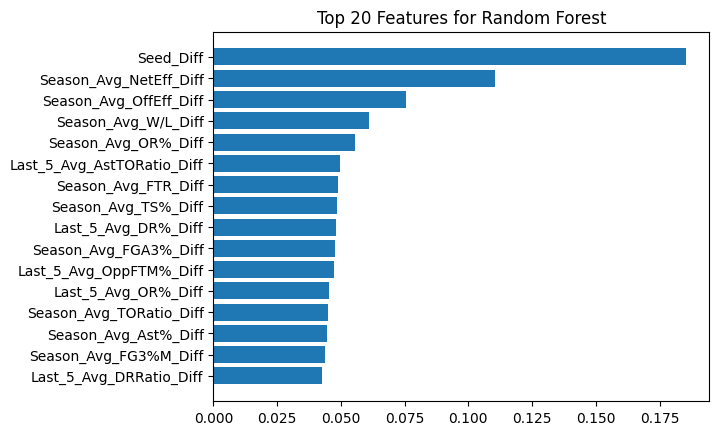

In [11]:
forestImportances = forest.feature_importances_
forestIndices = forestImportances.argsort()
plt.barh(finalFeaturesNP[forestIndices][-20:], forestImportances[forestIndices][-20:])
plt.title('Top 20 Features for Random Forest')
plt.show()

# Logistic Regression

In [12]:
# Train logistic regression
LR = LogisticRegression(
    random_state=42
)
LR.fit(XTrain, YTrain)
print(f'Training accuracy: {LR.score(XTrain, YTrain)}')
print(f'Testing accuracy from {TEST_YEAR}: {LR.score(XTest, YTest)}')
print(f'Brier score: {brier_score_loss(YTest, LR.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, LR.predict_proba(XTest))}')

Training accuracy: 0.7429701230228472
Testing accuracy from 2025: 0.7835820895522388
Brier score: 0.14352755609982054
Log Loss: 0.4391710240894436


In [13]:
# Train calibrated base logistic regression
caliLRBaseModel = LogisticRegression(
    random_state=42
)

caliLRBase = CalibratedClassifierCV(
    caliLRBaseModel,
    method='sigmoid',
    cv=3
)

caliLRBase.fit(XTrain, YTrain)
print(f'Training accuracy: {caliLRBase.score(XTrain, YTrain)}')
print(f'Testing accuracy from {TEST_YEAR}: {caliLRBase.score(XTest, YTest)}')
print(f'Brier score: {brier_score_loss(YTest, caliLRBase.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, caliLRBase.predict_proba(XTest))}')

Training accuracy: 0.742311072056239
Testing accuracy from 2025: 0.7835820895522388
Brier score: 0.14367558321217244
Log Loss: 0.44011240352236636


In [14]:
# Train tuned logistic regression
bestLR = LogisticRegression(
    random_state=42,
    C=0.1623776739188721,
    class_weight='balanced',
    l1_ratio=0.05,
    penalty='elasticnet',
    solver='saga'
)

bestLR.fit(XTrain, YTrain)
print(f'Training accuracy: {bestLR.score(XTrain, YTrain)}')
print(f'Testing accuracy from {TEST_YEAR}: {bestLR.score(XTest, YTest)}')
print(f'Brier score: {brier_score_loss(YTest, bestLR.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, bestLR.predict_proba(XTest))}')

Training accuracy: 0.742091388400703
Testing accuracy from 2025: 0.7835820895522388
Brier score: 0.14333072363930105
Log Loss: 0.439259662857593


In [15]:
# Train calibrated tuned logistic regression
caliLRTunedModel = LogisticRegression(
    random_state=42
)

caliLRTuned = CalibratedClassifierCV(
    caliLRTunedModel,
    method='sigmoid',
    cv=3
)

caliLRTuned.fit(XTrain, YTrain)
print(f'Training accuracy: {caliLRTuned.score(XTrain, YTrain)}')
print(f'Testing accuracy from {TEST_YEAR}: {caliLRTuned.score(XTest, YTest)}')
print(f'Brier score: {brier_score_loss(YTest, caliLRTuned.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, caliLRTuned.predict_proba(XTest))}')

Training accuracy: 0.742311072056239
Testing accuracy from 2025: 0.7835820895522388
Brier score: 0.14367558321217244
Log Loss: 0.44011240352236636


In [16]:
# # Grid Search for logistic regression
# LRParams = [
# 
#     {
#         'solver': ['lbfgs'],
#         'penalty': ['l2'],
#         'C': np.logspace(-5, 3, 30),
#         'multi_class': ['auto', 'multinomial'],
#         'class_weight': [None, 'balanced'],
#         'fit_intercept': [True, False],
#     },
# 
#     {
#         'solver': ['newton-cg'],
#         'penalty': ['l2'],
#         'C': np.logspace(-5, 3, 30),
#         'multi_class': ['auto', 'multinomial'],
#         'class_weight': [None, 'balanced'],
#         'fit_intercept': [True, False],
#     },
# 
#     {
#         'solver': ['newton-cholesky'],
#         'penalty': ['l2'],
#         'C': np.logspace(-5, 3, 30),
#         'multi_class': ['auto', 'multinomial'],
#         'class_weight': [None, 'balanced'],
#         'fit_intercept': [True, False],
#     },
# 
#     {
#         'solver': ['sag'],
#         'penalty': ['l2'],
#         'C': np.logspace(-5, 3, 30),
#         'multi_class': ['auto', 'multinomial'],
#         'class_weight': [None, 'balanced'],
#         'fit_intercept': [True, False],
#     },
# 
#     {
#         'solver': ['liblinear'],
#         'penalty': ['l1', 'l2'],
#         'C': np.logspace(-5, 3, 30),
#         'class_weight': [None, 'balanced'],
#         'fit_intercept': [True, False],
#         'dual': [False],
#     },
# 
#     {
#         'solver': ['saga'],
#         'penalty': ['l1', 'l2', 'elasticnet'],
#         'C': np.logspace(-5, 3, 30),
#         'l1_ratio': np.linspace(0, 1, 10),  # used only for elasticnet
#         'multi_class': ['auto', 'multinomial'],
#         'class_weight': [None, 'balanced'],
#         'fit_intercept': [True, False],
#     }
# ]
# 
# LRGridModel = LogisticRegression(max_iter=5000)
# LRGrid = GridSearchCV(estimator=LRGridModel, param_grid=LRParams, cv=3, scoring='neg_brier_score', verbose=2)
# LRGrid.fit(XTrain, YTrain)
# LRGrid.best_params_

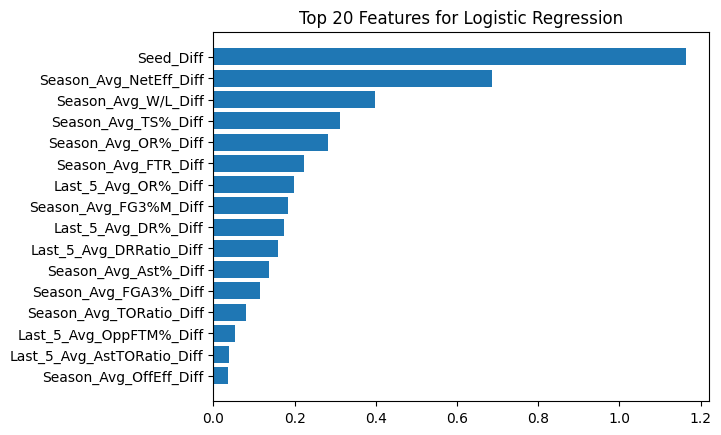

In [17]:
coefficients = LR.coef_[0]
LRIndices = np.argsort(np.abs(coefficients))
plt.barh(finalFeaturesNP[LRIndices][-20:], np.abs(coefficients[LRIndices][-20:]))
plt.title('Top 20 Features for Logistic Regression')
plt.show()

# XGBoost

In [18]:
# Train XGBoost model
bst = XGBClassifier(
    random_state=42
)

bst.fit(XTrain, YTrain)

trainPred = bst.predict(XTrain)
testPred = bst.predict(XTest)
print(f'Training accuracy: {accuracy_score(YTrain, trainPred)}')
print(f'Testing accuracy from {TEST_YEAR}: {accuracy_score(YTest, testPred)}')
print(f'Brier score: {brier_score_loss(YTest, bst.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, bst.predict_proba(XTest))}')

Training accuracy: 0.9989015817223199
Testing accuracy from 2025: 0.7910447761194029
Brier score: 0.1495326588882486
Log Loss: 0.4619086071538779


In [19]:
# Train calibrated base xgboost
caliXGBBaseModel = XGBClassifier(
    random_state=42
)

caliXGBBase = CalibratedClassifierCV(
    caliXGBBaseModel,
    method='sigmoid',
    cv=3
)

caliXGBBase.fit(XTrain, YTrain)
trainPredCaliXGBBase = caliXGBBase.predict(XTrain)
testPredCaliXGBBase = caliXGBBase.predict(XTest)
print(f'Training accuracy: {accuracy_score(YTrain, trainPredCaliXGBBase)}')
print(f'Testing accuracy from {TEST_YEAR}: {accuracy_score(YTest, testPredCaliXGBBase)}')
print(f'Brier score: {brier_score_loss(YTest, caliXGBBase.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, caliXGBBase.predict_proba(XTest))}')

Training accuracy: 0.9995606326889279
Testing accuracy from 2025: 0.7835820895522388
Brier score: 0.15724012079797098
Log Loss: 0.48868435068654525


In [20]:
# Train tuned xgboost model
bestXGB = XGBClassifier(
    random_state=42,
    colsample_bytree=0.7,
    max_depth=3,
    min_child_weight=10,
    reg_lambda=5,
    subsample=0.7,
    n_estimators=200,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1
)

bestXGB.fit(XTrain, YTrain)

trainPred = bestXGB.predict(XTrain)
testPred = bestXGB.predict(XTest)
print(f'Training accuracy: {accuracy_score(YTrain, trainPred)}')
print(f'Testing accuracy from {TEST_YEAR}: {accuracy_score(YTest, testPred)}')
print(f'Brier score: {brier_score_loss(YTest, bestXGB.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, bestXGB.predict_proba(XTest))}')

Training accuracy: 0.8732425307557118
Testing accuracy from 2025: 0.7649253731343284
Brier score: 0.16024224367518175
Log Loss: 0.48006289695262266


In [21]:
# Train calibrated tuned xgboost
caliXGBTunedModel = XGBClassifier(
    random_state=42,
    colsample_bytree=0.7,
    max_depth=3,
    min_child_weight=10,
    reg_lambda=5,
    subsample=0.7,
    n_estimators=200,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1
)

caliXGBTuned = CalibratedClassifierCV(
    caliXGBTunedModel,
    method='isotonic',
    cv=3
)

caliXGBTuned.fit(XTrain, YTrain)
trainPredCaliXGBTuned = caliXGBTuned.predict(XTrain)
testPredCaliXGBTuned = caliXGBTuned.predict(XTest)
print(f'Training accuracy: {accuracy_score(YTrain, trainPredCaliXGBTuned)}')
print(f'Testing accuracy from {TEST_YEAR}: {accuracy_score(YTest, testPredCaliXGBTuned)}')
print(f'Brier score: {brier_score_loss(YTest, caliXGBTuned.predict_proba(XTest)[:, 1])}')
print(f'Log Loss: {log_loss(YTest, caliXGBTuned.predict_proba(XTest))}')

Training accuracy: 0.8569859402460457
Testing accuracy from 2025: 0.7686567164179104
Brier score: 0.16054347063635188
Log Loss: 0.4825815040014587


In [22]:
# # Grid Search for xgb
# xgbParams = {
#     'n_estimators': [200, 400],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 5, 10],
#     'subsample': [0.7, 0.9],
#     'colsample_bytree': [0.7, 0.9],
#     'gamma': [0, 1],
#     'reg_lambda': [1, 5],
#     'reg_alpha': [0, 1],
# }
# 
# xgbGridModel = XGBClassifier(
#     objective='binary:logistic',
#     eval_metric='logloss',
#     n_jobs=-1
# )
# 
# xgbGrid = GridSearchCV(estimator=xgbGridModel, param_grid=xgbParams, cv=3, scoring='neg_brier_score', verbose=2)
# xgbGrid.fit(XTrain, YTrain)
# xgbGrid.best_params_

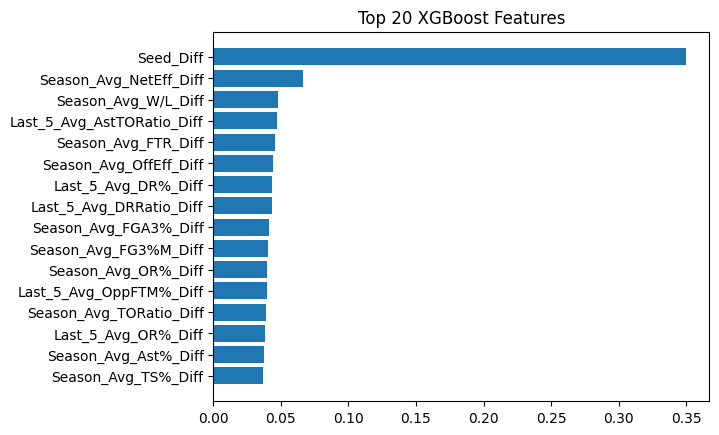

In [23]:
bstImportance = bst.feature_importances_
bstIndices = np.argsort(bstImportance)
plt.barh(finalFeaturesNP[bstIndices][-20:], bstImportance[bstIndices][-20:])
plt.title('Top 20 XGBoost Features')
plt.show()

In [24]:
# Set intersection on best 30 features across 3 models
forestTop = set(finalFeaturesNP[forestIndices][-30:])
LRTop = set(finalFeaturesNP[LRIndices][-30:])
bstTop = set(finalFeaturesNP[bstIndices][-30:])

# Compute Intersect
commonTop = forestTop & LRTop & bstTop
commonTop

{'Last_5_Avg_AstTORatio_Diff',
 'Last_5_Avg_DR%_Diff',
 'Last_5_Avg_DRRatio_Diff',
 'Last_5_Avg_OR%_Diff',
 'Last_5_Avg_OppFTM%_Diff',
 'Season_Avg_Ast%_Diff',
 'Season_Avg_FG3%M_Diff',
 'Season_Avg_FGA3%_Diff',
 'Season_Avg_FTR_Diff',
 'Season_Avg_NetEff_Diff',
 'Season_Avg_OR%_Diff',
 'Season_Avg_OffEff_Diff',
 'Season_Avg_TORatio_Diff',
 'Season_Avg_TS%_Diff',
 'Season_Avg_W/L_Diff',
 'Seed_Diff'}

# Competition Submission

In [25]:
'''
Function to take example submission dataframe seperate one column into 3.
param df: dataframe with single column 'ID'. Expects '2025_1101_1102' format
return: dataframe with three columns ['Season', 'Team1', 'Team2']
'''
def splitSubmission(df):
    splitData = df['ID'].str.split('_', expand=True)
    df[['Season', 'Team1', 'Team2']] = splitData.astype(int)
    df.drop(columns=['ID', 'Pred'], inplace=True)
    return df


'''
Function to take example submission dataframe seperate one column into 3.
param tourn: dataframe of tournament pairings with columns ['Season', 'Team1', 'Team2']
param seed: dataframe of mens and womens seeds with columns ['Season', 'TeamID, 'Seed']
return: dataframe with three columns ['Season', 'Team1', 'Team2']
'''
def mergeSeedSubmission(tourn, seed):
    # Merge seed for team1
    tournFinal = tourn.merge(
        right=seed,
        how='left',
        left_on=['Season', 'Team1'],
        right_on=['Season', 'TeamID'],
    ).rename(columns={'Seed': 'Seed_T1'}).drop(columns='TeamID')
    
    # Merge seed for team2
    tournFinal = tournFinal.merge(
        right=seed,
        how='left',
        left_on=['Season', 'Team2'],
        right_on=['Season', 'TeamID'],
    ).rename(columns={'Seed': 'Seed_T2'}).drop(columns='TeamID')
    
    # Replace seeds for teams that did not make tourney for 2026
    tournFinal.fillna(16, inplace=True)
    return tournFinal


'''
Function to calculate difference in teams input features for final prediction
param tourn: dataframe of all team pairings for 2026 with columns ['Season', 'Team1', 'Team2', 'Team1Seed', 'Team2Seed']
param features: dataframe of input features with columns ['Season', 'TeamID']
return: dataframe of differences for training
'''
def calculateDifferenceFinal(tourn, features):
    # Merge two team stats from RegSeasonFeatures
    TourneyFinal = tourn.merge(features, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], suffixes=('', '_T1'))
    TourneyFinal = TourneyFinal.merge(features, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], suffixes=('_T1', '_T2'))

    # Calculate the differences (Team1 - Team2) for the features for input
    featureCols = [col for col in features if col not in ['Season', 'TeamID']] + ['Seed']
    for col in featureCols:
        TourneyFinal[col + '_Diff'] = TourneyFinal[col + '_T1'] - TourneyFinal[col + '_T2']

    # Drop all _T1 and _T2, keep only _Diff
    TourneyFinal = TourneyFinal[['Season', 'Team1', 'Team2'] + [col + '_Diff' for col in featureCols]]
    return TourneyFinal

In [26]:
# Competition input
finalPairings = pd.read_csv('submission/input/SampleSubmissionStage2.csv')
compTourn = splitSubmission(finalPairings.copy())

# Join mens and womens seeds
joinedSeeds = pd.concat([mCleanSeeds, wCleanSeeds], ignore_index=True)

# Merge seeds with competition tournament pairings
compTournFinal = mergeSeedSubmission(compTourn, joinedSeeds)

# Merge competition pairings with regular season features
compTournInput = calculateDifferenceFinal(compTournFinal, finalAvgFeatures)
inputFinal = compTournInput[[
    'Last_5_Avg_AstTORatio_Diff',
    'Last_5_Avg_DR%_Diff',
    'Last_5_Avg_DRRatio_Diff',
    'Last_5_Avg_OR%_Diff',
    'Last_5_Avg_OppFTM%_Diff',
    'Season_Avg_Ast%_Diff',
    'Season_Avg_FG3%M_Diff',
    'Season_Avg_FGA3%_Diff',
    'Season_Avg_FTR_Diff',
    'Season_Avg_NetEff_Diff',
    'Season_Avg_OR%_Diff',
    'Season_Avg_OffEff_Diff',
    'Season_Avg_TORatio_Diff',
    'Season_Avg_TS%_Diff',
    'Season_Avg_W/L_Diff',
    'Seed_Diff'
]]

# Scale input for models
inputFinal = scaler.transform(inputFinal)

In [27]:
# Sanity check
compTournInput[(compTournInput['Team1'] == 1181) & (compTournInput['Team2'] == 1373)]

,Season,Team1,Team2,Season_Avg_TORatio_Diff,Season_Avg_FG3%M_Diff,Season_Avg_FGA3%_Diff,Season_Avg_FTM%_Diff,Season_Avg_OppFTM%_Diff,Season_Avg_FTR_Diff,Season_Avg_OppFTR_Diff,...,Last_5_Avg_DefEff_Diff,Last_5_Avg_NetEff_Diff,Last_5_Avg_TO%_Diff,Last_5_Avg_Ast%_Diff,Last_5_Avg_AstTORatio_Diff,Last_5_Avg_AstRatio_Diff,Last_5_Avg_OR%_Diff,Last_5_Avg_DR%_Diff,Last_5_Avg_TS%_Diff,Seed_Diff
24420,2026,1181,1373,-0.1120703149,0.0503566128,0.1271855695,-0.0546229061,-0.0096261418,0.0245744875,-0.0402607141,...,0.0721039650,0.0848567826,0.0089579038,-0.0680960494,0.3098917749,0.0287301587,0.1647151121,0.1026175638,0.0386345061,-15.0000000000


# Predict for all Models

In [28]:
'''
Function to predict and save submission for all models
param models: list of all trained models to predict with (must support predict_proba)
param outNames: list of all names for output files matching index for models param
param pairings: df of submission file to append predictions to
param compInput: dataframe with input data for predictions 
'''
def predictModels(models, outNames, pairings, compInput):
    for i, model in enumerate(models):
        # Create a copy of pairings to keep fresh during loops
        submission = pairings.copy()
        
        # Make prediction
        proba = model.predict_proba(compInput)
        submission['Pred'] = proba[:, 1]
        
        # Save submission
        submission.to_csv(f'submission/{outNames[i]}.csv', index=False)
    return 

In [29]:
# Generate submission file for all models
models = [
    forest,
    caliForestBase,
    bestForest,
    caliForestTuned,
    LR,
    caliLRBase,
    bestLR,
    caliLRTuned,
    bst,
    caliXGBBase,
    bestXGB,
    caliXGBTuned
]

modelFileNames = [
    'Forest.Base',
    'Forest.Calibrated.Base',
    'Forest.Tuned',
    'Forest.Calibrated.Tuned',
    'LR.Base',
    'LR.Calibrated.Base',
    'LR.Tuned',
    'LR.Calibrated.Tuned',
    'XGB.Base',
    'XGB.Calibrated.Base',
    'XGB.Tuned',
    'XGB.Calibrated.Tuned'
]

# Catch mistakes
if len(models) == len(modelFileNames):
    predictModels(models, modelFileNames, finalPairings, inputFinal)
else:
    print('Model list length and name list length mismatch')

In [30]:
# Sanity check for base forest
submitForest = finalPairings.copy()
forestProba = forest.predict_proba(inputFinal)[:, 1]
submitForest['Pred'] = forestProba

team1 = 1257
team2 = 1378
submitForest[(submitForest['ID'] == f'2026_{team1}_{team2}')]

,ID,Pred
43110,2026_1257_1378,0.6336633663
